In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [23]:
titanic = sns.load_dataset("titanic")

feature = ["pclass", "sex", "age", "fare", "embarked"]
target = ["survived"]

#missing data
imp = SimpleImputer(strategy="mean")
titanic[["age"]] = imp.fit_transform(titanic[["age"]])
imp2 = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp2.fit_transform(titanic[["embarked"]])

#encoding
le = LabelEncoder()
titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

#train
X = titanic[feature]
y = titanic["survived"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.33, random_state=42
)

In [24]:
#Decision Tree
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print("Accuracy train :", accuracy_score(y_train,y_pred_train)*100,"%")
print("Accuracy test :", accuracy_score(y_test,y_pred_test)*100,"%")

Accuracy train : 97.81879194630872 %
Accuracy test : 73.89830508474576 %


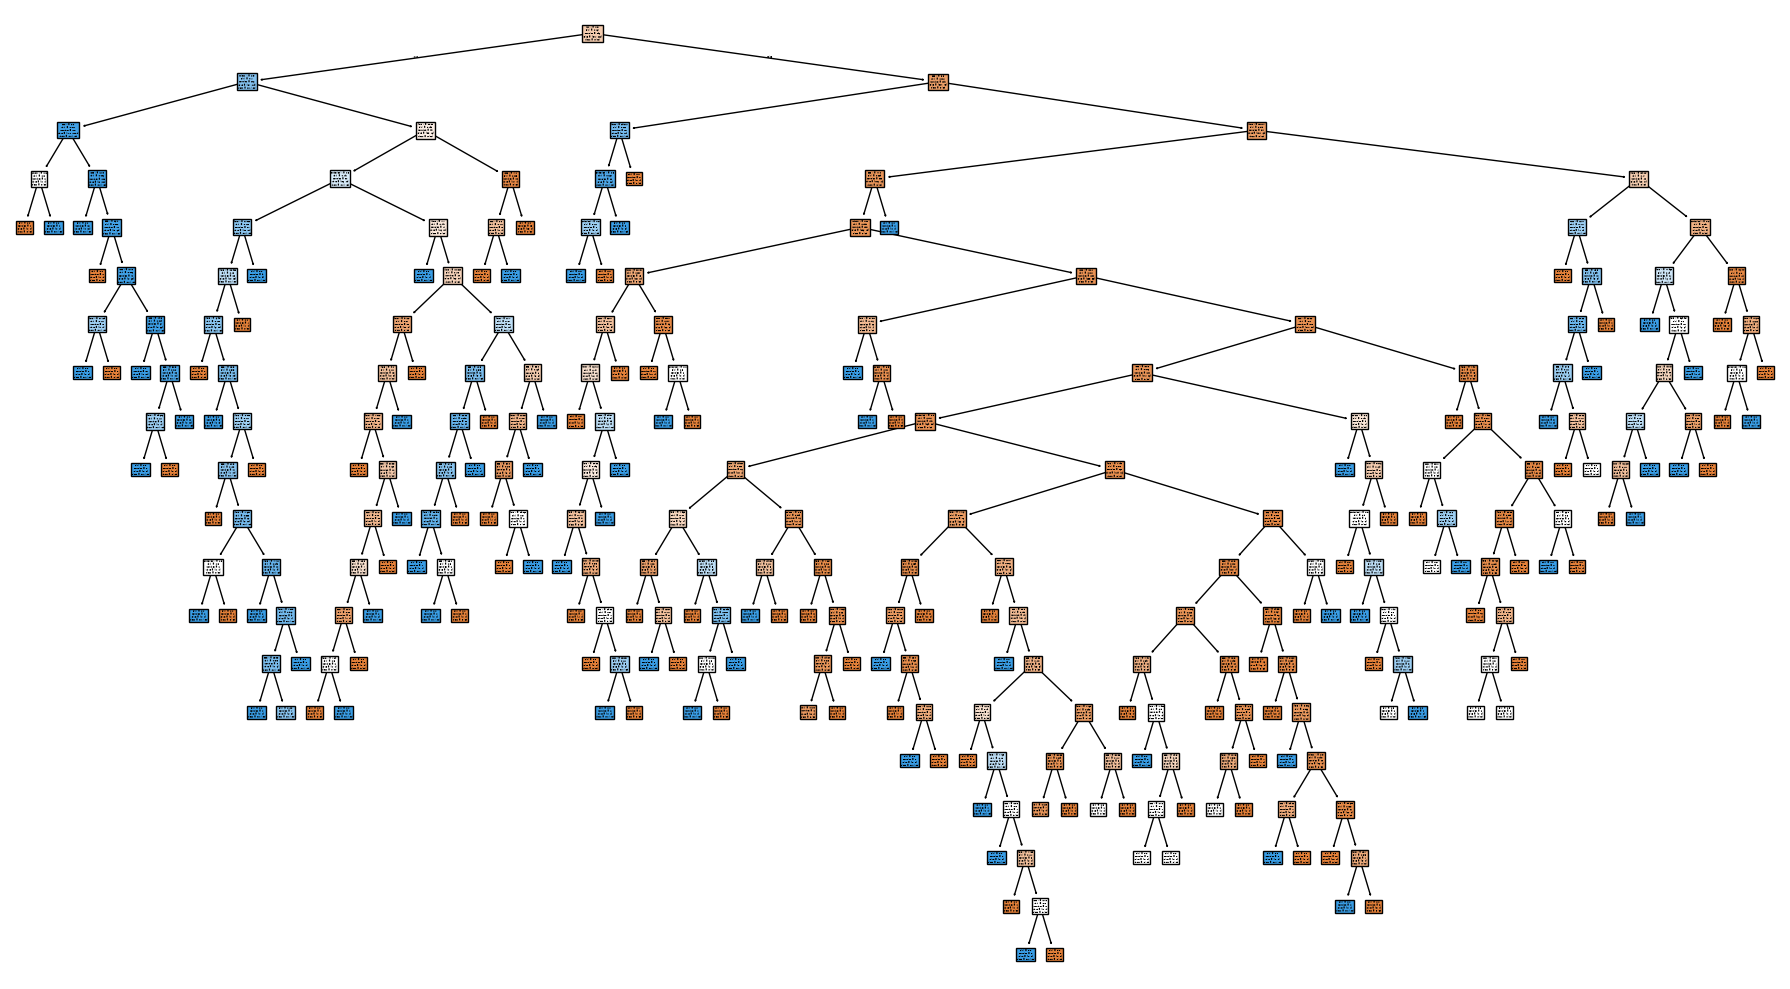

In [27]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.tight_layout()

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=501,
    max_depth=4,
    oob_score=True
)

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

print("OOB score :", rf.oob_score_*100,"%")
print("Accuracy :", accuracy_score(y_test,y_pred)*100,"%")

OOB score : 80.87248322147651 %
Accuracy : 82.03389830508473 %


In [33]:
# Bagging classifier
from sklearn.ensemble import BaggingClassifier

base_model = DecisionTreeClassifier()

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train,y_train)

y_pred = bagging.predict(X_test)

print("Accuracy :", accuracy_score(y_test,y_pred)*100,"%")

Accuracy : 78.64406779661017 %


In [35]:
# Bagging classifier
from sklearn.linear_model import LogisticRegression

base_model = LogisticRegression(max_iter=1000)

bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)

bagging.fit(X_train,y_train)

y_pred = bagging.predict(X_test)

print("Accuracy :", accuracy_score(y_test,y_pred)*100,"%")

Accuracy : 80.0 %
